Manual Accuracy: 0.89
Manual Precision: 0.9230769230769231
Manual Recall: 0.8571428571428571
Manual AUC: 0.9560131649172745


/tmp/ipython-input-319/553709603.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_manual = np.trapz(TPR, FPR)


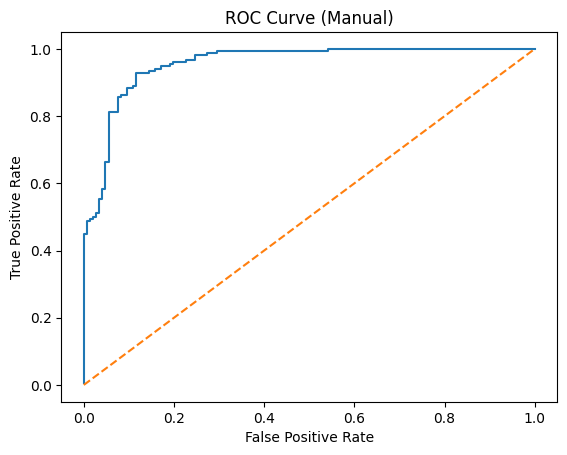

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X, y = make_classification(n_samples=1000, n_features=5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

TP = sum((y_pred == 1) & (y_test == 1))
TN = sum((y_pred == 0) & (y_test == 0))
FP = sum((y_pred == 1) & (y_test == 0))
FN = sum((y_pred == 0) & (y_test == 1))

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("Manual Accuracy:", accuracy)
print("Manual Precision:", precision)
print("Manual Recall:", recall)

thresholds = np.sort(y_prob)[::-1]
TPR = []
FPR = []

P = sum(y_test == 1)
N = sum(y_test == 0)

for thresh in thresholds:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    TP_t = sum((y_pred_thresh == 1) & (y_test == 1))
    FP_t = sum((y_pred_thresh == 1) & (y_test == 0))
    TPR.append(TP_t / P)
    FPR.append(FP_t / N)

auc_manual = np.trapz(TPR, FPR)

print("Manual AUC:", auc_manual)

plt.figure()
plt.plot(FPR, TPR)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Manual)")
plt.show()

Accuracy: 0.89
Precision: 0.9230769230769231
Recall: 0.8571428571428571
AUC: 0.9560131649172745


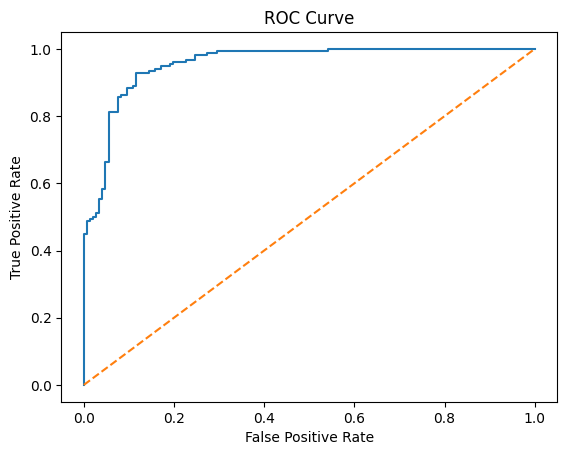

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, roc_auc_score

X, y = make_classification(n_samples=1000, n_features=5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("AUC:", auc_score)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()